# Libraries and functions

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation


def _extract_metric_at_epoch(eval_epochs, metric_values, epoch=None):
    eval_epochs = np.asarray(eval_epochs)
    metric_values = np.asarray(metric_values, dtype=float)

    if metric_values.size == 0:
        return np.nan

    if epoch is None:
        return float(metric_values[-1])

    matches = np.where(eval_epochs == epoch)[0]
    if len(matches) == 0:
        return np.nan
    return float(metric_values[matches[-1]])


def available_common_epochs(data):
    epochs_list = []
    for arr in data["eval_epochs"]:
        arr = np.asarray(arr, dtype=int)
        if arr.size > 0:
            epochs_list.append(set(arr.tolist()))

    if not epochs_list:
        return []

    common = set.intersection(*epochs_list)
    return sorted(common)


def build_phase_diagram_arrays(
    npz_path,
    metric_key="test_loss_std_mse",
    epoch=None,
):
    data = np.load(npz_path, allow_pickle=True)

    lr = np.asarray(data["lr"], dtype=float)
    inv_sigma_w = np.asarray(data["inv_sigma_w"], dtype=float)

    lr_vals = np.sort(np.unique(lr))
    inv_sigma_vals = np.sort(np.unique(inv_sigma_w))

    # y-axis = lr, x-axis = inv_sigma_w
    phase_matrix = np.full((len(lr_vals), len(inv_sigma_vals)), np.nan, dtype=float)
    counts_matrix = np.zeros((len(lr_vals), len(inv_sigma_vals)), dtype=int)

    scalar_metric_keys = {
        "final_train_loss_std_mse",
        "final_test_loss_std_mse",
        "final_train_mae_years",
        "final_test_mae_years",
        "final_train_mse_years",
        "final_test_mse_years",
    }

    for i_lr, lr_val in enumerate(lr_vals):
        for j_inv, inv_val in enumerate(inv_sigma_vals):
            mask = (lr == lr_val) & (inv_sigma_w == inv_val)
            idxs = np.where(mask)[0]

            vals = []
            for idx in idxs:
                if metric_key in scalar_metric_keys:
                    v = float(data[metric_key][idx])
                else:
                    eval_epochs = data["eval_epochs"][idx]
                    metric_values = data[metric_key][idx]
                    v = _extract_metric_at_epoch(eval_epochs, metric_values, epoch=epoch)

                if np.isfinite(v):
                    vals.append(v)
                if v>100:
                    vals.append(100)

            if len(vals) > 0:
                phase_matrix[i_lr, j_inv] = float(np.mean(vals))
                counts_matrix[i_lr, j_inv] = len(vals)

    return inv_sigma_vals, lr_vals, phase_matrix, counts_matrix

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


def _log_edges_from_centers(vals, base=2.0):
    vals = np.asarray(vals, dtype=float)

    if np.any(vals <= 0):
        raise ValueError("All values must be positive for log-scale axes.")

    log_vals = np.log(vals) / np.log(base)

    if len(log_vals) == 1:
        d = 0.5
        log_edges = np.array([log_vals[0] - d, log_vals[0] + d])
    else:
        mids = 0.5 * (log_vals[:-1] + log_vals[1:])
        first = log_vals[0] - 0.5 * (log_vals[1] - log_vals[0])
        last = log_vals[-1] + 0.5 * (log_vals[-1] - log_vals[-2])
        log_edges = np.concatenate([[first], mids, [last]])

    return base ** log_edges


def _make_base2_ticks_and_labels(
    exp_min,
    exp_max,
    *,
    tick_every_exponents=2,
    label_every_n_ticks=2,
):
    """
    Example:
      exp_min=-10, exp_max=10
      tick_every_exponents=2  -> ticks at -10, -8, -6, ..., 10
      label_every_n_ticks=2   -> labels only at -10, -6, -2, 2, 6, 10
    """
    exp_min = int(exp_min)
    exp_max = int(exp_max)
    tick_every_exponents = int(tick_every_exponents)
    label_every_n_ticks = int(label_every_n_ticks)

    if tick_every_exponents <= 0:
        raise ValueError("tick_every_exponents must be positive.")
    if label_every_n_ticks <= 0:
        raise ValueError("label_every_n_ticks must be positive.")
    if exp_max < exp_min:
        raise ValueError("exp_max must be >= exp_min.")

    exponents = np.arange(exp_min, exp_max + 1, tick_every_exponents, dtype=int)
    tick_values = 2.0 ** exponents

    tick_labels = []
    for i, e in enumerate(exponents):
        if i % label_every_n_ticks == 0:
            tick_labels.append(rf"$2^{{{e}}}$")
        else:
            tick_labels.append("")

    return tick_values, tick_labels


def plot_phase_diagram_imshow(
    npz_path,
    metric_key="test_loss_std_mse",
    epoch=None,
    title=False,
    annotate=False,
    figsize=(6, 5),
    name_cbar=None,
    color_cut=None,
    vmin=None,
    vmax=None,
):
    inv_sigma_vals, lr_vals, phase_matrix, counts_matrix = build_phase_diagram_arrays(
        npz_path=npz_path,
        metric_key=metric_key,
        epoch=epoch,
    )

    phase_matrix = np.asarray(phase_matrix, dtype=float)

    # This is the matrix used only for the colors.
    # The original phase_matrix is kept unchanged and returned.
    plot_matrix = np.array(phase_matrix, copy=True)

    if color_cut is not None:
        plot_matrix = np.minimum(plot_matrix, float(color_cut))

    masked = np.ma.masked_invalid(plot_matrix)

    cmap = mpl.colormaps["viridis"].copy()
    cmap.set_bad(color="lightgray")

    fig, ax = plt.subplots(figsize=figsize)

    if vmax is None and color_cut is not None:
        vmax = float(color_cut)

    im = ax.imshow(
        masked,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(inv_sigma_vals)))
    ax.set_xticklabels([f"{x:g}" for x in inv_sigma_vals], rotation=45)

    ax.set_yticks(np.arange(len(lr_vals)))
    ax.set_yticklabels([f"{x:g}" for x in lr_vals])

    ax.set_xlabel(r"$1/\sigma_W$", fontsize=30)
    ax.set_ylabel(r"$\epsilon$", fontsize=30)

    if title is True:
        if epoch is None:
            ax.set_title(f"{metric_key} (last available epoch, mean over seeds)")
        else:
            ax.set_title(f"{metric_key} (epoch={epoch}, mean over seeds)")

    cbar = plt.colorbar(im, ax=ax)

    # if name_cbar is not None:
    #     cbar.set_label(name_cbar)
    # else:
    #     cbar.set_label(metric_key)

    if color_cut is not None:
        cbar.ax.set_title(rf"$\geq {color_cut:g}$", fontsize=9)

    if annotate:
        for i in range(phase_matrix.shape[0]):
            for j in range(phase_matrix.shape[1]):
                if np.isnan(phase_matrix[i, j]):
                    txt = "NaN"
                elif color_cut is not None and phase_matrix[i, j] > color_cut:
                    txt = rf"$>{color_cut:g}$"
                else:
                    txt = f"{phase_matrix[i, j]:.3g}"

                ax.text(j, i, txt, ha="center", va="center", fontsize=8)

    plt.tight_layout()

    return fig, ax, inv_sigma_vals, lr_vals, phase_matrix, counts_matrix

In [21]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, Tuple, List, Any

import numpy as np


def print_lr_inv_sigma_combo_matrix(save_folder: str | Path):
    """
    Read an experiment-2 output folder and print the matrix of (a,b) indices
    for the (lr, inv_sigma_w) combinations found there.

    Convention:
    - a = index of lr in sorted(unique_lrs)
    - b = index of inv_sigma_w in sorted(unique_inv_sigmas)

    Rows correspond to inv_sigma_w values (sorted increasing).
    Columns correspond to lr values (sorted increasing).

    Parameters
    ----------
    save_folder : str or Path
        Folder containing combo_* subfolders produced by experiment 2.

    Returns
    -------
    result : dict with keys
        - matrix_labels: 2D object array with entries like "(a,b)"
        - matrix_combo_index: 2D float array with combo_index where present, nan otherwise
        - unique_lrs: sorted list of lr values
        - unique_inv_sigmas: sorted list of inv_sigma_w values
        - combo_map: dict[(a,b)] -> info
    """
    save_folder = Path(save_folder).expanduser().resolve()
    if not save_folder.exists():
        raise FileNotFoundError(f"Folder not found: {save_folder}")

    combo_dirs = sorted([p for p in save_folder.glob("combo_*") if p.is_dir()])
    if not combo_dirs:
        raise RuntimeError(f"No combo_* folders found inside {save_folder}")

    records: List[Dict[str, Any]] = []

    for combo_dir in combo_dirs:
        seed_dirs = sorted([p for p in combo_dir.glob("seed_*") if p.is_dir()])
        if not seed_dirs:
            continue

        # Use the first seed folder, since lr and inv_sigma_w are the same for all seeds
        run_spec_path = seed_dirs[0] / "run_spec.json"
        if not run_spec_path.exists():
            continue

        with open(run_spec_path, "r", encoding="utf-8") as f:
            run_spec = json.load(f)

        train = run_spec.get("train", {})
        lr = float(train["lr"])
        inv_sigma_w = float(train["inv_sigma_w"])
        combo_index = int(run_spec.get("combo_index", -1))

        records.append(
            {
                "combo_dir": combo_dir,
                "combo_index": combo_index,
                "lr": lr,
                "inv_sigma_w": inv_sigma_w,
            }
        )

    if not records:
        raise RuntimeError(f"No valid run_spec.json files found under {save_folder}")

    unique_lrs = sorted({r["lr"] for r in records})
    unique_inv_sigmas = sorted({r["inv_sigma_w"] for r in records})

    lr_to_a = {lr: a for a, lr in enumerate(unique_lrs)}
    inv_sigma_to_b = {inv_sigma: b for b, inv_sigma in enumerate(unique_inv_sigmas)}

    n_rows = len(unique_inv_sigmas)
    n_cols = len(unique_lrs)

    matrix_labels = np.full((n_rows, n_cols), "", dtype=object)
    matrix_combo_index = np.full((n_rows, n_cols), np.nan, dtype=float)

    combo_map: Dict[Tuple[int, int], Dict[str, Any]] = {}

    for r in records:
        a = lr_to_a[r["lr"]]
        b = inv_sigma_to_b[r["inv_sigma_w"]]

        # rows = inv_sigma index, cols = lr index
        matrix_labels[b, a] = f"({a},{b})"
        matrix_combo_index[b, a] = r["combo_index"]

        combo_map[(a, b)] = {
            "combo_index": r["combo_index"],
            "lr": r["lr"],
            "inv_sigma_w": r["inv_sigma_w"],
            "combo_dir": str(r["combo_dir"]),
        }

    print("\nColumns = lr values")
    for a, lr in enumerate(unique_lrs):
        print(f"  a={a}: lr={lr}")

    print("\nRows = inv_sigma_w values")
    for b, inv_sigma in enumerate(unique_inv_sigmas):
        print(f"  b={b}: inv_sigma_w={inv_sigma}")

    print("\nMatrix of (a,b) labels  [rows = inv_sigma_w, cols = lr]:\n")
    print(matrix_labels)

    print("\nMatrix of combo_index  [rows = inv_sigma_w, cols = lr]:\n")
    print(matrix_combo_index)

    return {
        "matrix_labels": matrix_labels,
        "matrix_combo_index": matrix_combo_index,
        "unique_lrs": unique_lrs,
        "unique_inv_sigmas": unique_inv_sigmas,
        "combo_map": combo_map,
    }

In [22]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, Tuple, List, Any, Sequence

import torch
import numpy as np
import matplotlib.pyplot as plt


def plot_svd_histograms_for_combo(
    save_folder: str | Path,
    combo: Tuple[int, int],
    epochs: Sequence[int],
    *,
    which: str = "weight",
    seed: int | None = None,
    svd_filename: str = "svd_diagnostics.pt",
    bins: int = 30,
    density: bool = False,
    log_x: bool = False,
    log_y: bool = False,
    figsize_per_panel: Tuple[float, float] = (4.5, 2.8),
):
    """
    Plot histograms of saved SVD singular values for one combo (a,b) at selected epochs.

    Parameters
    ----------
    save_folder : str or Path
        Root experiment folder containing combo_* directories.
    combo : tuple[int, int]
        (a,b) where
        - a = index in sorted unique lr values
        - b = index in sorted unique inv_sigma_w values
    epochs : sequence[int]
        Epochs to plot, e.g. [1, 10, 100]
    which : {"weight", "grad"}
        Whether to plot weight singular values or gradient singular values.
    seed : int or None
        If None, uses the first seed folder found inside the combo folder.
        Otherwise selects the seed_<seed>_* folder.
    svd_filename : str
        Name of the saved SVD diagnostics file.
    bins : int
        Number of histogram bins.
    density : bool
        Passed to matplotlib hist.
    log_x : bool
        If True, x axis is logarithmic when possible.
    log_y : bool
        If True, y axis is logarithmic.
    figsize_per_panel : tuple[float, float]
        Size multiplier per subplot.

    Returns
    -------
    out : dict
        Contains figure, axes, combo info, and loaded diagnostics.
    """
    if which not in {"weight", "grad"}:
        raise ValueError("which must be 'weight' or 'grad'.")

    save_folder = Path(save_folder).expanduser().resolve()
    epochs = [int(e) for e in epochs]
    a, b = int(combo[0]), int(combo[1])

    # ------------------------------------------------------------------
    # Step 1: reconstruct mapping (a,b) -> combo_dir using run_spec.json
    # ------------------------------------------------------------------
    combo_dirs = sorted([p for p in save_folder.glob("combo_*") if p.is_dir()])
    if not combo_dirs:
        raise RuntimeError(f"No combo_* folders found in {save_folder}")

    records: List[Dict[str, Any]] = []
    for combo_dir in combo_dirs:
        seed_dirs = sorted([p for p in combo_dir.glob("seed_*") if p.is_dir()])
        if not seed_dirs:
            continue

        run_spec_path = seed_dirs[0] / "run_spec.json"
        if not run_spec_path.exists():
            continue

        with open(run_spec_path, "r", encoding="utf-8") as f:
            run_spec = json.load(f)

        train = run_spec.get("train", {})
        if "lr" not in train or "inv_sigma_w" not in train:
            continue

        records.append(
            {
                "combo_dir": combo_dir,
                "lr": float(train["lr"]),
                "inv_sigma_w": float(train["inv_sigma_w"]),
                "combo_index": int(run_spec.get("combo_index", -1)),
            }
        )

    if not records:
        raise RuntimeError(f"No valid run_spec.json found under {save_folder}")

    unique_lrs = sorted({r["lr"] for r in records})
    unique_inv_sigmas = sorted({r["inv_sigma_w"] for r in records})

    if not (0 <= a < len(unique_lrs)):
        raise IndexError(f"a={a} out of range. Valid range: 0..{len(unique_lrs)-1}")
    if not (0 <= b < len(unique_inv_sigmas)):
        raise IndexError(f"b={b} out of range. Valid range: 0..{len(unique_inv_sigmas)-1}")

    target_lr = unique_lrs[a]
    target_inv_sigma = unique_inv_sigmas[b]

    matched = [
        r for r in records
        if r["lr"] == target_lr and r["inv_sigma_w"] == target_inv_sigma
    ]
    if len(matched) == 0:
        raise RuntimeError(f"No combo folder found for combo (a,b)=({a},{b})")

    if len(matched) > 1:
        raise RuntimeError(f"More than one combo folder matched combo (a,b)=({a},{b})")

    combo_info = matched[0]
    combo_dir = combo_info["combo_dir"]

    # ------------------------------------------------------------------
    # Step 2: choose seed folder
    # ------------------------------------------------------------------
    seed_dirs = sorted([p for p in combo_dir.glob("seed_*") if p.is_dir()])
    if not seed_dirs:
        raise RuntimeError(f"No seed_* folders found in {combo_dir}")

    if seed is None:
        seed_dir = seed_dirs[0]
    else:
        candidates = [p for p in seed_dirs if p.name.startswith(f"seed_{int(seed):04d}_")]
        if not candidates:
            raise RuntimeError(f"No seed folder found for seed={seed} in {combo_dir}")
        seed_dir = candidates[0]

    svd_path = seed_dir / svd_filename
    if not svd_path.exists():
        raise FileNotFoundError(
            f"SVD diagnostics file not found:\n{svd_path}\n"
            f"Did you run the experiment with COMPUTE_SVD_DIAGNOSTICS=1?"
        )

    d = torch.load(svd_path, map_location="cpu")

    by_epoch = d.get("by_epoch", {})
    if not by_epoch:
        raise RuntimeError(f"No 'by_epoch' data found inside {svd_path}")

    # ------------------------------------------------------------------
    # Step 3: determine layer order from first requested available epoch
    # ------------------------------------------------------------------
    first_epoch_key = None
    for ep in epochs:
        ep_key = str(int(ep))
        if ep_key in by_epoch:
            first_epoch_key = ep_key
            break
    if first_epoch_key is None:
        available = sorted(int(k) for k in by_epoch.keys())
        raise RuntimeError(
            f"None of the requested epochs {list(epochs)} are present.\n"
            f"Available epochs: {available}"
        )

    layer_order = by_epoch[first_epoch_key].get("layer_order", None)
    if not layer_order:
        layer_order = sorted(by_epoch[first_epoch_key]["layers"].keys())

    n_layers = len(layer_order)
    n_epochs = len(epochs)

    fig_w = figsize_per_panel[0] * n_epochs
    fig_h = figsize_per_panel[1] * n_layers
    fig, axes = plt.subplots(n_layers, n_epochs, figsize=(fig_w, fig_h), squeeze=False)

    value_key = "weight_singular_values" if which == "weight" else "grad_singular_values"

    # ------------------------------------------------------------------
    # Step 4: plot
    # ------------------------------------------------------------------
    for i, layer_name in enumerate(layer_order):
        for j, ep in enumerate(epochs):
            ax = axes[i, j]
            ep_key = str(int(ep))

            if ep_key not in by_epoch:
                ax.text(0.5, 0.5, f"epoch {ep}\nmissing", ha="center", va="center")
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            epoch_layers = by_epoch[ep_key]["layers"]
            if layer_name not in epoch_layers:
                ax.text(0.5, 0.5, f"{layer_name}\nmissing", ha="center", va="center")
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            values = np.asarray(epoch_layers[layer_name][value_key], dtype=float)

            finite_mask = np.isfinite(values)
            values = values[finite_mask]

            if values.size == 0:
                ax.text(0.5, 0.5, "no finite values", ha="center", va="center")
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            # If log_x, keep only strictly positive values
            if log_x:
                values = values[values > 0.0]
                if values.size == 0:
                    ax.text(0.5, 0.5, "no positive values\nfor log-x", ha="center", va="center")
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue

            ax.hist(values, bins=bins, density=density)

            if log_x:
                ax.set_xscale("log")
            if log_y:
                ax.set_yscale("log")

            if i == 0:
                ax.set_title(f"epoch {ep}", fontsize=11)

            if j == 0:
                ax.set_ylabel(layer_name, fontsize=10)

            if i == n_layers - 1:
                if which == "weight":
                    ax.set_xlabel("weight singular value")
                else:
                    ax.set_xlabel("gradient singular value")

    fig.suptitle(
        f"SVD histograms for combo (a,b)=({a},{b}) | "
        f"lr={target_lr:g}, inv_sigma_w={target_inv_sigma:g} | "
        f"seed_dir={seed_dir.name} | which={which}",
        fontsize=12,
        y=0.995,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    return {
        "figure": fig,
        "axes": axes,
        "combo_dir": combo_dir,
        "seed_dir": seed_dir,
        "svd_path": svd_path,
        "diagnostics": d,
        "layer_order": layer_order,
        "unique_lrs": unique_lrs,
        "unique_inv_sigmas": unique_inv_sigmas,
        "target_lr": target_lr,
        "target_inv_sigma_w": target_inv_sigma,
    }

In [23]:
# at the top of the notebook/script
from global_chanju.paulplot.rc_setter import set_rc, get_rc
from global_chanju.paulplot.styles import nice_style

set_rc(scale=1.0)

plt.rcParams.update({
    "text.usetex": False,          # keep False if LaTeX is not installed
    "font.family": "serif",
    "mathtext.fontset": "cm",      # Computer Modern math
    "axes.formatter.use_mathtext": True,
})

In [24]:
from pathlib import Path
import json
import random
import numpy as np


IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def compute_utkface_age_baselines_from_config(
    config_path,
    repo_root="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD",
):
    config_path = Path(config_path).resolve()
    repo_root = Path(repo_root).resolve()

    with open(config_path, "r") as f:
        cfg = json.load(f)

    dataset_cfg = dict(cfg["dataset"])

    # Compatibility with your different config names
    root = (
        dataset_cfg.get("root_dir")
        or dataset_cfg.get("root")
        or dataset_cfg.get("image_dir")
        or dataset_cfg.get("images_dir")
    )

    if root is None:
        raise ValueError("Could not find dataset root. Expected one of: root, root_dir, image_dir, images_dir.")

    root = Path(root)
    if not root.is_absolute():
        root = repo_root / root

    max_images = dataset_cfg.get("max_images", dataset_cfg.get("max_samples", None))

    if "test_fraction" in dataset_cfg:
        test_fraction = float(dataset_cfg["test_fraction"])
    elif "train_fraction" in dataset_cfg:
        test_fraction = 1.0 - float(dataset_cfg["train_fraction"])
    else:
        test_fraction = 0.1

    seed = int(dataset_cfg.get("split_seed", dataset_cfg.get("shuffle_seed", 12345)))

    # Same logic as your regression_datasets.py:
    # collect images, parse age from filename, shuffle, optionally cut max_images
    items = []
    for p in root.rglob("*"):
        if not p.is_file():
            continue
        if p.name.startswith("."):
            continue
        if p.suffix.lower() not in IMAGE_EXTS:
            continue

        try:
            age = float(p.name.split("_")[0])
        except Exception:
            continue

        if 0 <= age <= 120:
            items.append((p, age))

    if len(items) == 0:
        raise RuntimeError(f"No UTKFace-style files found under: {root}")

    rng = random.Random(seed)
    rng.shuffle(items)

    if max_images is not None:
        items = items[:int(max_images)]

    ages = np.array([age for _, age in items], dtype=np.float64)

    # Same split style as your copied regression_datasets.py:
    # np.random.default_rng(seed).permutation(n)
    n = len(ages)
    idx = np.random.default_rng(seed).permutation(n)

    n_test = int(round(n * test_fraction))
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]

    train_ages = ages[train_idx]
    test_ages = ages[test_idx]

    train_mean = float(train_ages.mean())
    train_median = float(np.median(train_ages))
    train_std = float(train_ages.std())

    mean_baseline_test_mae = float(np.mean(np.abs(test_ages - train_mean)))
    mean_baseline_test_mse = float(np.mean((test_ages - train_mean) ** 2))

    median_baseline_test_mae = float(np.mean(np.abs(test_ages - train_median)))
    median_baseline_test_mse = float(np.mean((test_ages - train_median) ** 2))

    mean_baseline_test_std_mse = float(mean_baseline_test_mse / (train_std ** 2))

    out = {
        "n_total": int(n),
        "n_train": int(len(train_ages)),
        "n_test": int(len(test_ages)),
        "seed": seed,
        "test_fraction": test_fraction,
        "train_mean_age": train_mean,
        "train_median_age": train_median,
        "train_std_age": train_std,
        "mean_baseline_test_mae_years": mean_baseline_test_mae,
        "mean_baseline_test_mse_years": mean_baseline_test_mse,
        "mean_baseline_test_std_mse": mean_baseline_test_std_mse,
        "median_baseline_test_mae_years": median_baseline_test_mae,
        "median_baseline_test_mse_years": median_baseline_test_mse,
        "train_ages": train_ages,
        "test_ages": test_ages,
    }

    print("UTKFace constant-predictor baselines")
    print("-----------------------------------")
    print(f"n_total = {out['n_total']}")
    print(f"n_train = {out['n_train']}")
    print(f"n_test  = {out['n_test']}")
    print(f"seed    = {out['seed']}")
    print()
    print(f"train mean age   = {train_mean:.4f}")
    print(f"train median age = {train_median:.4f}")
    print(f"train std age    = {train_std:.4f}")
    print()
    print(f"Mean-age predictor test MAE    = {mean_baseline_test_mae:.4f} years")
    print(f"Mean-age predictor test MSE    = {mean_baseline_test_mse:.4f} years^2")
    print(f"Mean-age predictor test stdMSE = {mean_baseline_test_std_mse:.4f}")
    print()
    print(f"Median-age predictor test MAE  = {median_baseline_test_mae:.4f} years")
    print(f"Median-age predictor test MSE  = {median_baseline_test_mse:.4f} years^2")

    return out

# Experiment 2 - CNN - old

## With SGD

In [21]:
data = np.load("collected_results/exp2_v6.npz", allow_pickle=True)

print(data.files)
print(data["lr"])
print(data["inv_sigma_w"])
print(data["final_test_loss_std_mse"])

['run_id', 'run_dir', 'dataset_root', 'architecture_json', 'dataset_json', 'train_json', 'eval_epochs', 'train_loss_std_mse', 'test_loss_std_mse', 'train_mae_years', 'test_mae_years', 'train_mse_years', 'test_mse_years', 'seed', 'lr', 'inv_sigma_w', 'sigma2_w', 'batch_size', 'epochs', 'n_train', 'n_test', 'target_mean_years', 'target_std_years', 'final_train_loss_std_mse', 'final_test_loss_std_mse', 'final_train_mae_years', 'final_test_mae_years', 'final_train_mse_years', 'final_test_mse_years']
[0.004 0.008 0.016 0.032 0.64  0.128 0.004 0.008 0.016 0.032 0.64  0.128
 0.004 0.008 0.016 0.032 0.64  0.128 0.004 0.008 0.016 0.032 0.64  0.128
 0.004 0.008 0.016 0.032 0.64  0.128 0.004 0.008 0.016 0.032 0.64  0.128]
[ 0.5  0.5  0.5  0.5  0.5  0.5  1.   1.   1.   1.   1.   1.   2.   2.
  2.   2.   2.   2.   4.   4.   4.   4.   4.   4.   8.   8.   8.   8.
  8.   8.  16.  16.  16.  16.  16.  16. ]
[       nan        nan        nan        nan        nan        nan
 0.33420071 0.28555817 0.25305

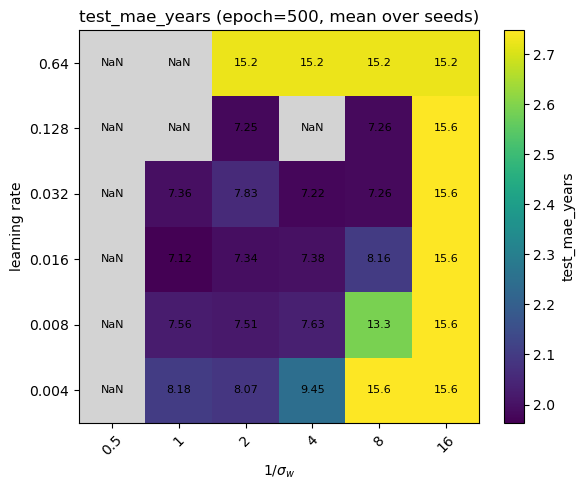

In [22]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_v6.npz",
    metric_key="test_mae_years",
    epoch=500,
    annotate=True,
)
plt.show()

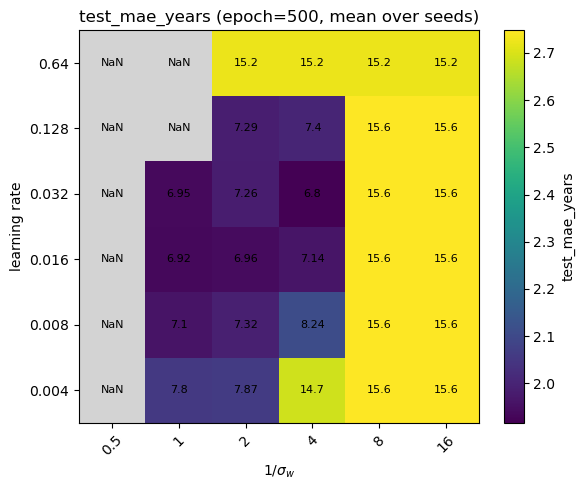

In [23]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_mlp_v1_sgd.npz",
    metric_key="test_mae_years",
    epoch=500,
    annotate=True,
)
plt.show()

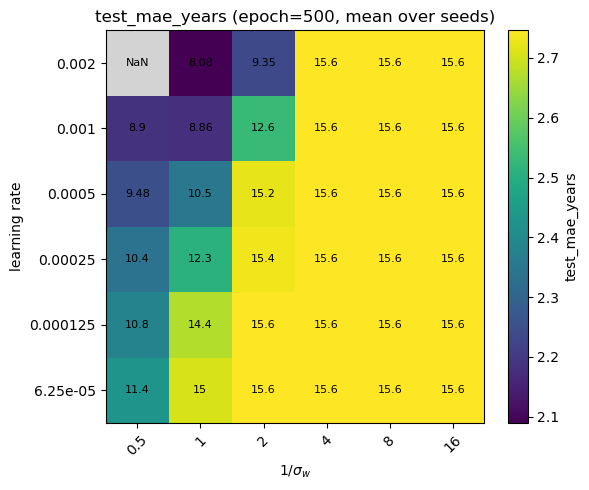

In [24]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_mlp_v5_sgd.npz",
    metric_key="test_mae_years",
    epoch=500,
    annotate=True,
)
plt.show()

## With AdaM

In [25]:
data = np.load("collected_results/exp2_v8.npz", allow_pickle=True)

print(data.files)
print(data["lr"])
print(data["inv_sigma_w"])
print(data["final_test_loss_std_mse"])

['run_id', 'run_dir', 'dataset_root', 'architecture_json', 'dataset_json', 'train_json', 'eval_epochs', 'train_loss_std_mse', 'test_loss_std_mse', 'train_mae_years', 'test_mae_years', 'train_mse_years', 'test_mse_years', 'seed', 'lr', 'inv_sigma_w', 'sigma2_w', 'batch_size', 'epochs', 'n_train', 'n_test', 'target_mean_years', 'target_std_years', 'final_train_loss_std_mse', 'final_test_loss_std_mse', 'final_train_mae_years', 'final_test_mae_years', 'final_train_mse_years', 'final_test_mse_years']
[0.004 0.008 0.016 0.032 0.64  0.128 0.004 0.008 0.016 0.032 0.64  0.128
 0.004 0.008 0.016 0.032 0.64  0.128 0.004 0.008 0.016 0.032 0.64  0.128
 0.004 0.008 0.016 0.032 0.64  0.128 0.004 0.008 0.016 0.032 0.64  0.128]
[ 0.5  0.5  0.5  0.5  0.5  0.5  1.   1.   1.   1.   1.   1.   2.   2.
  2.   2.   2.   2.   4.   4.   4.   4.   4.   4.   8.   8.   8.   8.
  8.   8.  16.  16.  16.  16.  16.  16. ]
[2.81379470e-01 3.51943527e-01 1.03213011e+00 1.03206822e+00
 1.03781024e+00 1.03736843e+00 4.078

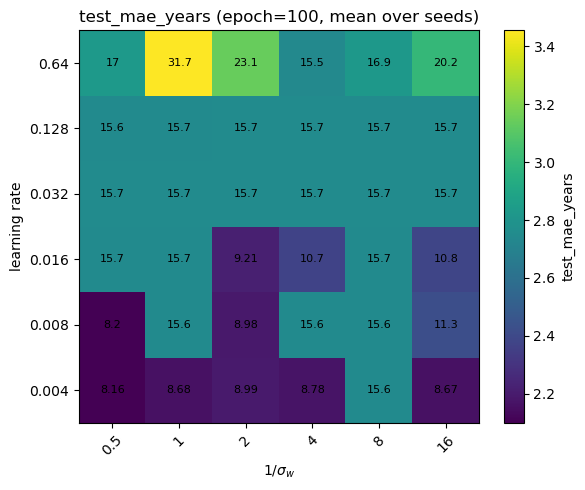

In [26]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_v8.npz",
    metric_key="test_mae_years",
    epoch= 100,
    annotate=True,
)
plt.show()

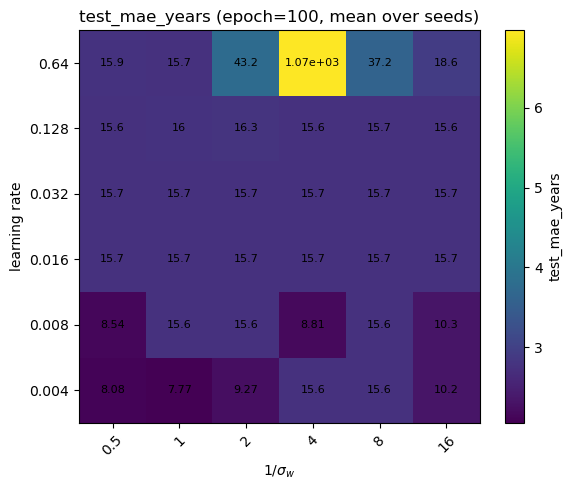

In [27]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_mlp_v4_adam.npz",
    metric_key="test_mae_years",
    epoch= 100,
    annotate=True,
)
plt.show()

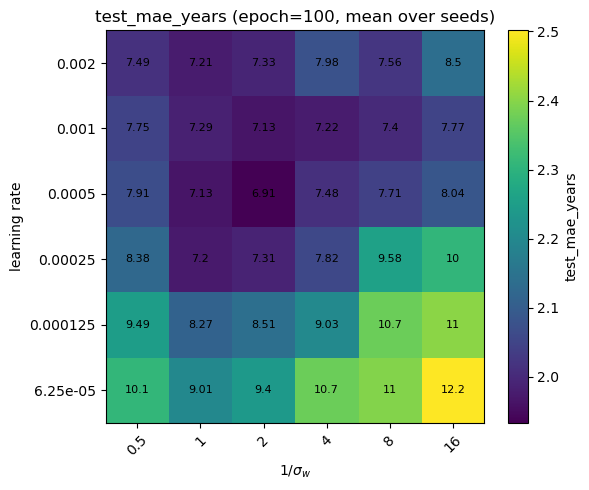

In [28]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_mlp_v5_adam.npz",
    metric_key="test_mae_years",
    epoch= 100,
    annotate=True,
)
plt.show()

# Experiment 2 - CNN

## SGD - 1 hidden MLP

### Relu

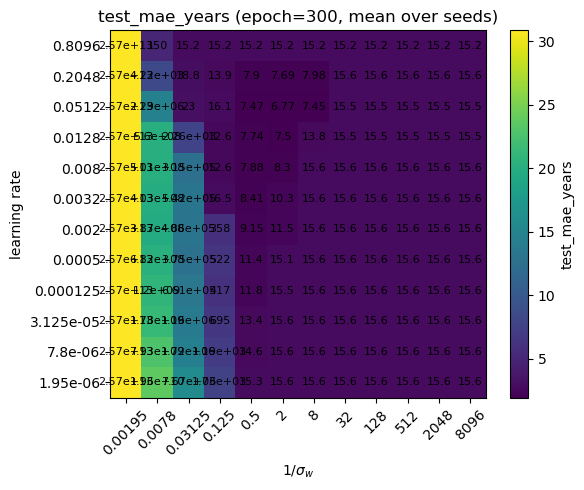

In [29]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_cnn_SMALL_sgd_relu_v3.npz",
    metric_key="test_mae_years",
    epoch= 300,
    annotate=True,
)
plt.show()

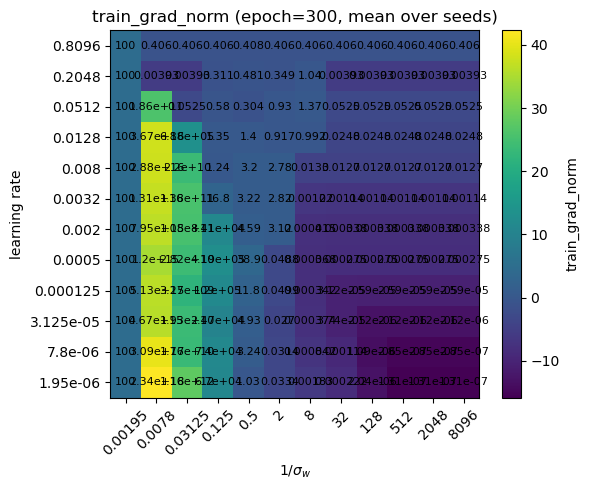

In [30]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_cnn_SMALL_sgd_relu_v3.npz",
    metric_key="train_grad_norm",
    epoch= 300,
    annotate=True,
)
plt.show()

## SGD 3 hidden MLP

### Relu

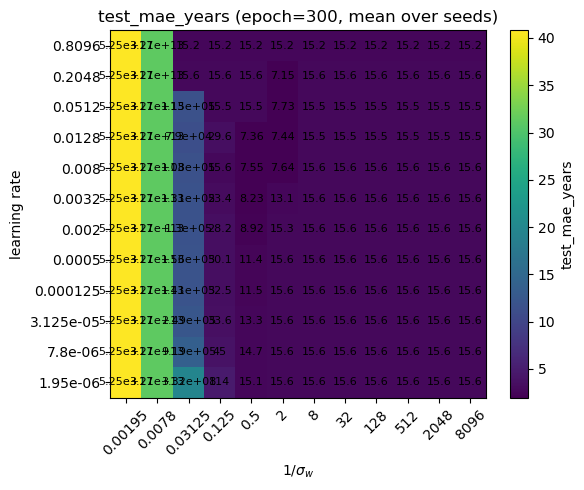

In [31]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_cnn_BIG_sgd_relu_v3.npz",
    metric_key="test_mae_years",
    epoch= 300,
    annotate=True,
)
plt.show()

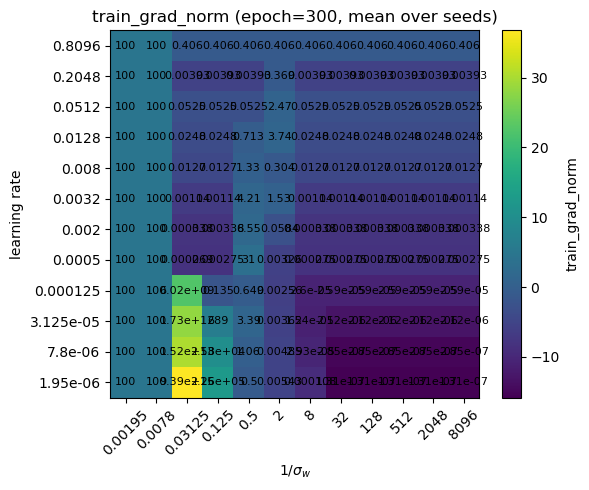

In [32]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_cnn_BIG_sgd_relu_v3.npz",
    metric_key="train_grad_norm",
    epoch= 300,
    annotate=True,
)
plt.show()

# Experiment 2 - DNN

## SGD - 1 hidden

### Relu

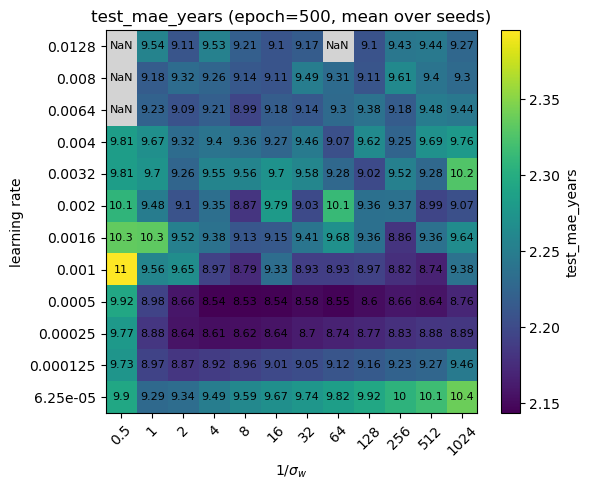

In [33]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_v1_sgd_relu.npz",
    metric_key="test_mae_years",
    epoch= 500,
    annotate=True,
)
plt.show()

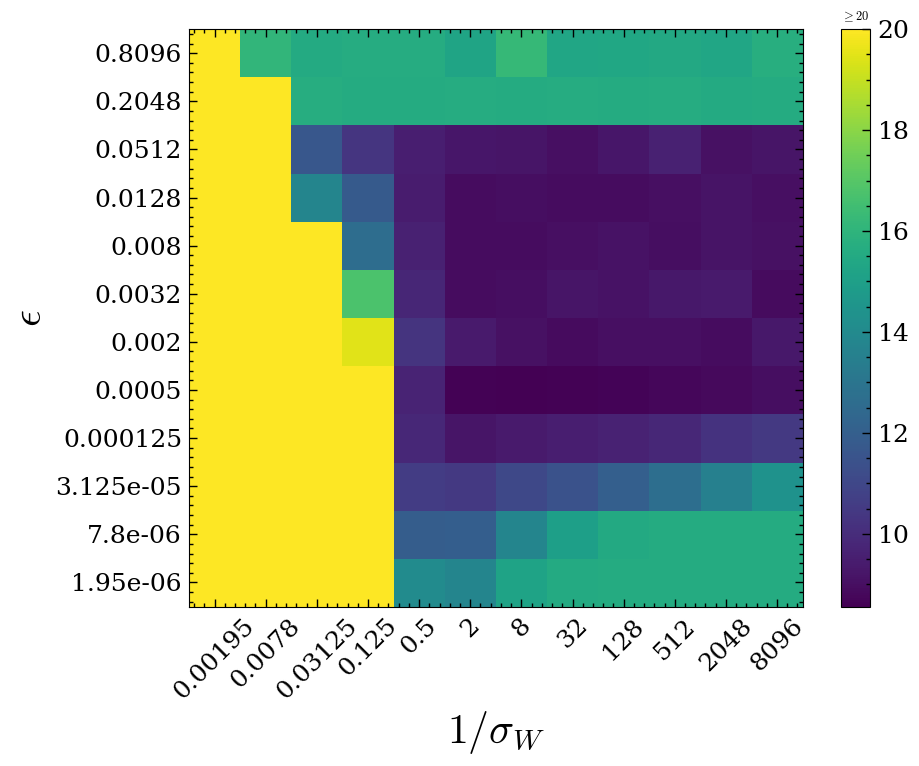

In [36]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_relu_v3.npz",
    metric_key="test_mae_years",
    epoch= 300,
    annotate=False,
    figsize=(10,8),
    name_cbar="Test error",
    color_cut = 20,
)

fig.savefig(
    "phase_diagram_faces.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

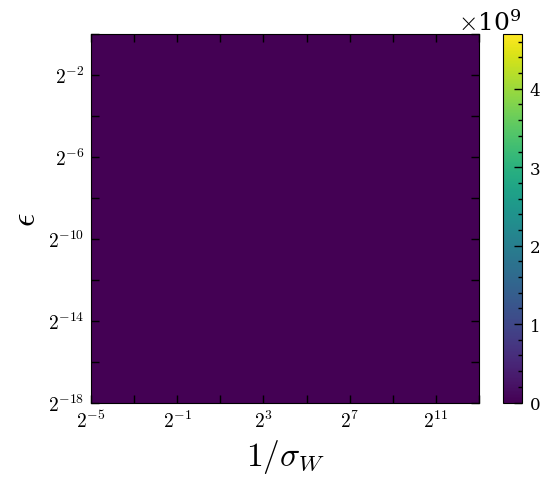

In [25]:
fig, ax, inv_sigma_vals, lr_vals, phase_matrix, counts_matrix = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_relu_v3.npz",
    metric_key="test_loss_std_mse",
    epoch=300,
    figsize=(6.2, 5.2),

    # set visible exponent range
    x_exp_min=-5,
    x_exp_max=13,
    y_exp_min=-18,
    y_exp_max=0,

    # ticks every 2 exponents, labels every 2 ticks
    tick_every_exponents=2,
    label_every_n_ticks=2,

    tick_label_fontsize=14,
    axis_label_fontsize=24,
)

# fig.savefig(
#     "phase_diagram.pdf",
#     format="pdf",
#     bbox_inches="tight",
#     dpi=300,
# )

plt.show()

In [28]:
baselines = compute_utkface_age_baselines_from_config(
    "/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/src/experiment_2/DNN_utkface_age_phase_diagram_q.json",
    repo_root="/mnt/beegfs/2a/mb12724/franc/BBP_in_SGD",
)

UTKFace constant-predictor baselines
-----------------------------------
n_total = 20000
n_train = 16000
n_test  = 4000
seed    = 12345

train mean age   = 33.3059
train median age = 29.0000
train std age    = 19.8814

Mean-age predictor test MAE    = 15.2402 years
Mean-age predictor test MSE    = 390.5452 years^2
Mean-age predictor test stdMSE = 0.9880

Median-age predictor test MAE  = 14.8760 years
Median-age predictor test MSE  = 410.2150 years^2


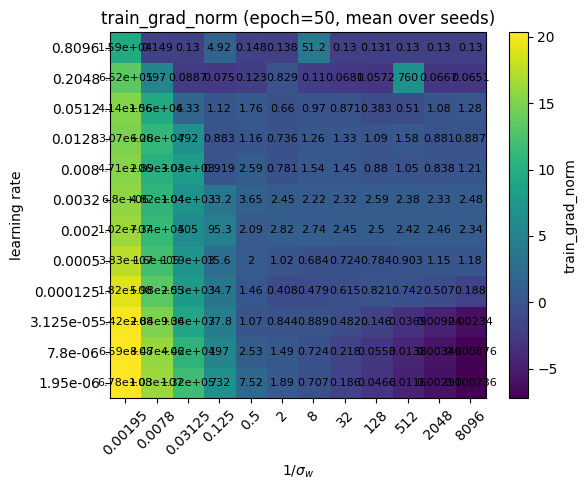

In [15]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_relu_v3.npz",
    metric_key="train_grad_norm",
    epoch= 50,
    annotate=True,
)
plt.show()

#### Full batch

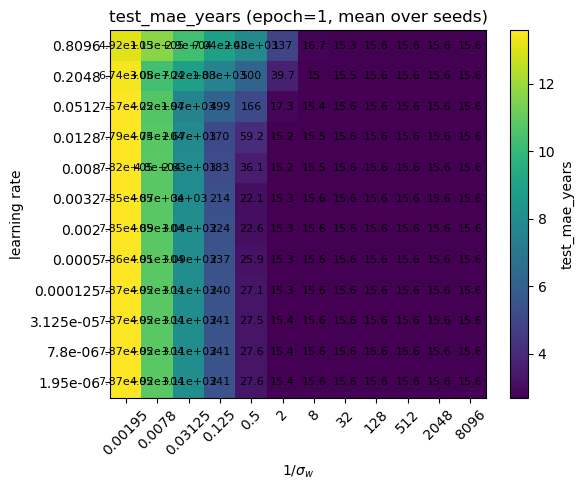

In [36]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_relu_full_v1.npz",
    metric_key="test_mae_years",
    epoch= 1,
    annotate=True,
)
plt.show()

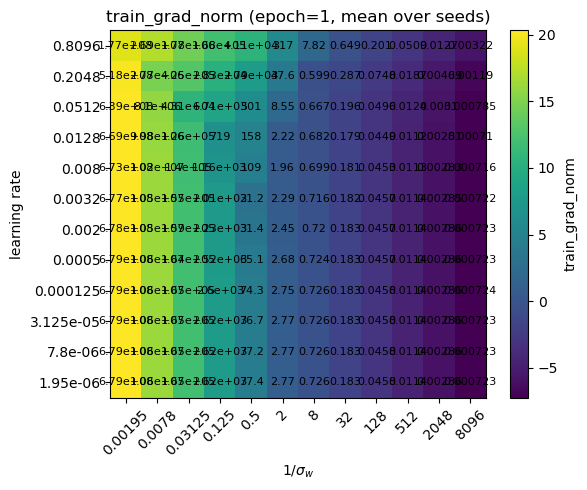

In [37]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_relu_full_v1.npz",
    metric_key="train_grad_norm",
    epoch= 1,
    annotate=True,
)
plt.show()

### tanh

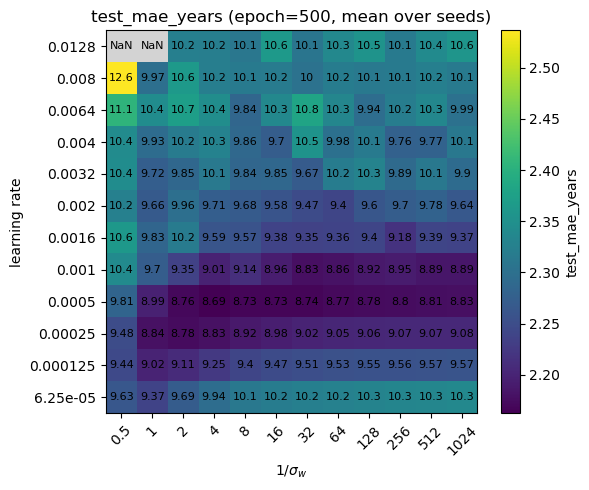

In [38]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_v1_sgd_tanh.npz",
    metric_key="test_mae_years",
    epoch= 500,
    annotate=True,
)
plt.show()

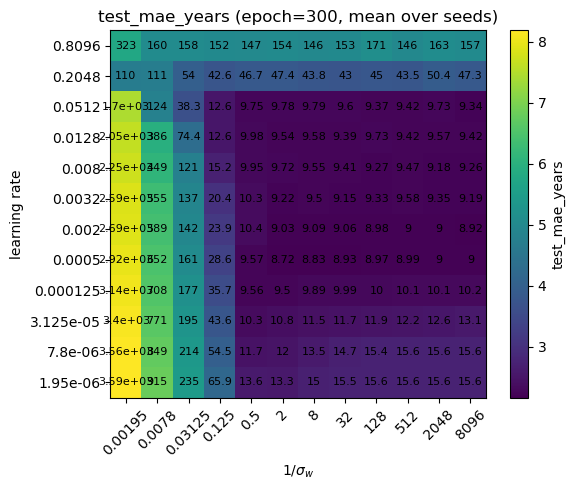

In [39]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_tanh_v3.npz",
    metric_key="test_mae_years",
    epoch= 300,
    annotate=True,
)
plt.show()

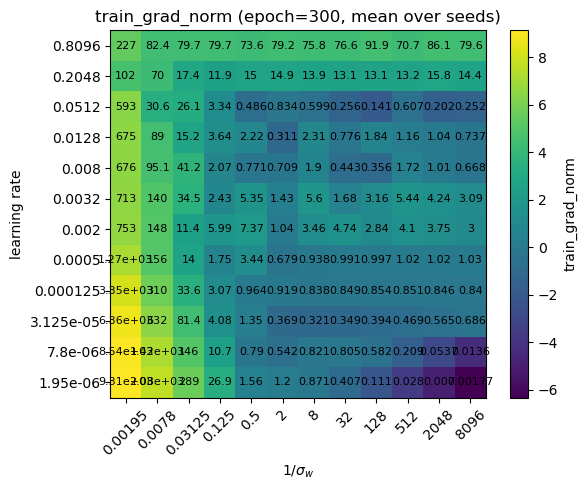

In [40]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_tanh_v3.npz",
    metric_key="train_grad_norm",
    epoch= 300,
    annotate=True,
)
plt.show()

#### Full batch

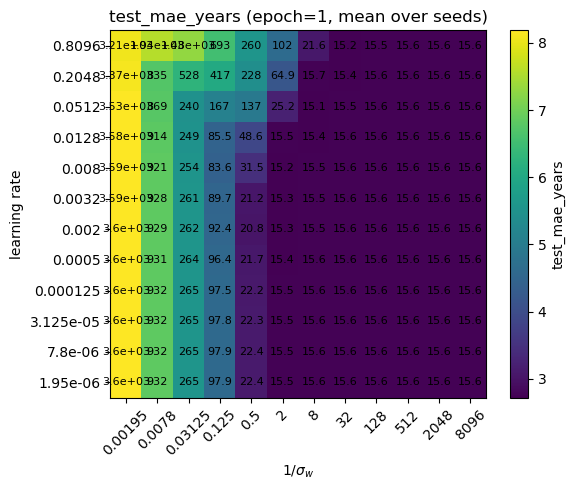

In [41]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_tanh_full_v1.npz",
    metric_key="test_mae_years",
    epoch= 1,
    annotate=True,
)
plt.show()

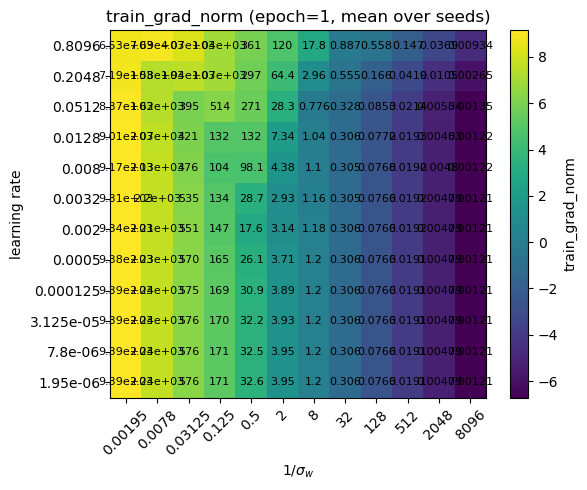

In [42]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_SMALL_sgd_tanh_full_v1.npz",
    metric_key="train_grad_norm",
    epoch= 1,
    annotate=True,
)
plt.show()

## SGD - three hidden

### relu

#### Minibatch

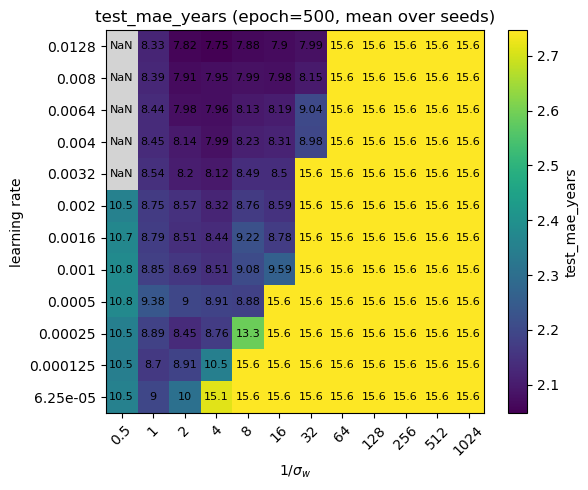

In [43]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_relu.npz",
    metric_key="test_mae_years",
    epoch= 500,
    annotate=True,
)
plt.show()

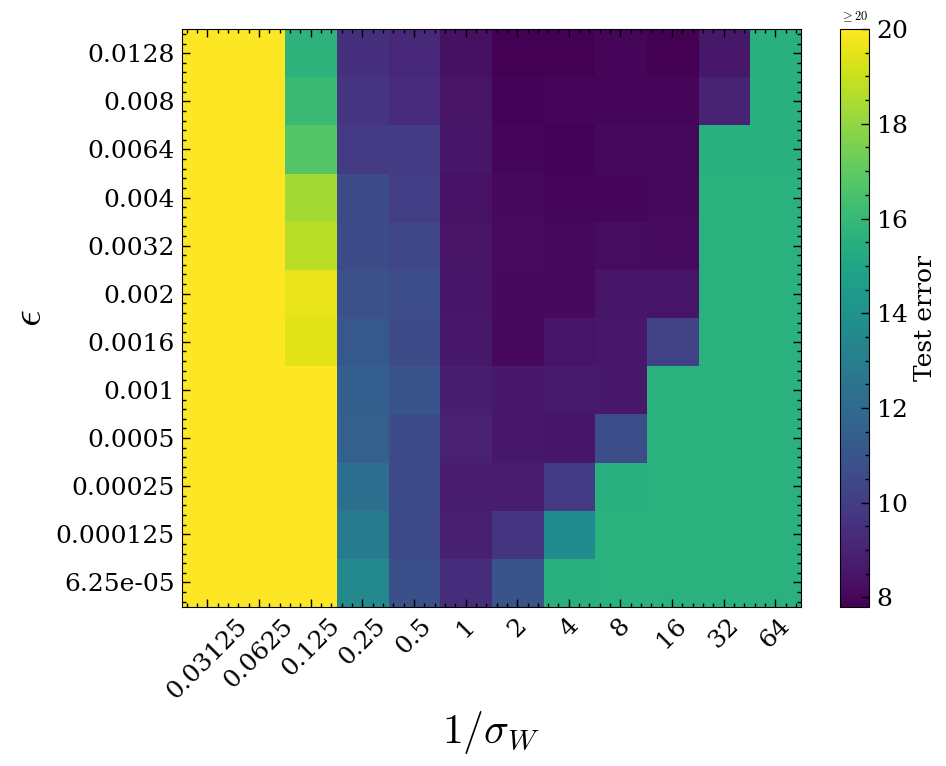

In [13]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_relu_v3.npz",
    metric_key="test_mae_years",
    epoch= 300,
    annotate=False,
    figsize=(10,8),
    name_cbar="Test error",
    color_cut = 20,
)
plt.show()



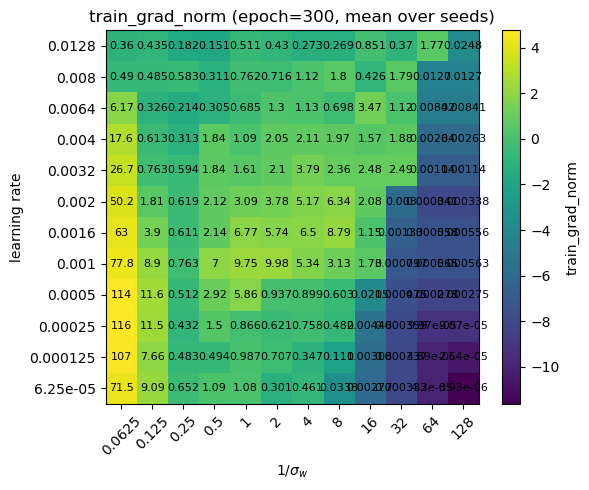

In [45]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh_v3.npz",
    metric_key="train_grad_norm",
    epoch= 300,
    annotate=True,
)
plt.show()

#### Full batch

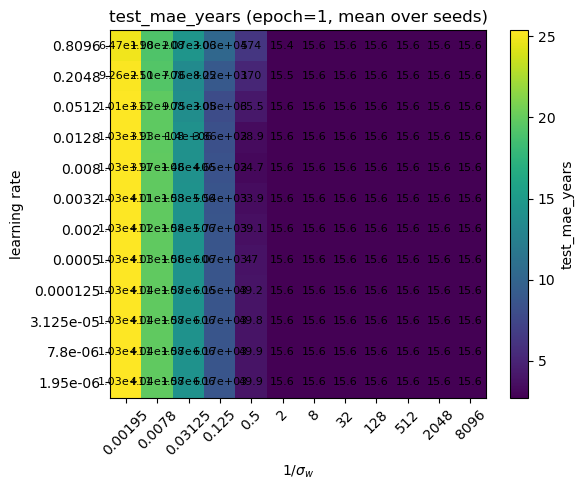

In [46]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_relu_full_v1.npz",
    metric_key="test_mae_years",
    epoch= 1,
    annotate=True,
)
plt.show()

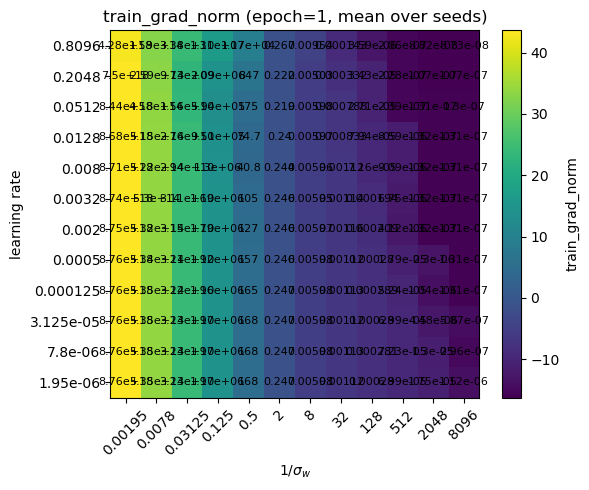

In [47]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_relu_full_v1.npz",
    metric_key="train_grad_norm",
    epoch= 1,
    annotate=True,
)
plt.show()

#### minibatch, SVD

In [6]:
out = print_lr_inv_sigma_combo_matrix("data/experiment_2/exp2_dnn_BIG_sgd_relu_SVD_v1")


Columns = lr values
  a=0: lr=1.95e-06
  a=1: lr=0.000125
  a=2: lr=0.008
  a=3: lr=0.0512
  a=4: lr=0.8096

Rows = inv_sigma_w values
  b=0: inv_sigma_w=0.00195
  b=1: inv_sigma_w=0.125
  b=2: inv_sigma_w=8.0
  b=3: inv_sigma_w=512.0
  b=4: inv_sigma_w=8096.0

Matrix of (a,b) labels  [rows = inv_sigma_w, cols = lr]:

[['(0,0)' '(1,0)' '(2,0)' '(3,0)' '(4,0)']
 ['(0,1)' '(1,1)' '(2,1)' '(3,1)' '(4,1)']
 ['(0,2)' '(1,2)' '(2,2)' '(3,2)' '(4,2)']
 ['(0,3)' '(1,3)' '(2,3)' '(3,3)' '(4,3)']
 ['(0,4)' '(1,4)' '(2,4)' '(3,4)' '(4,4)']]

Matrix of combo_index  [rows = inv_sigma_w, cols = lr]:

[[ 0.  1.  2.  3.  4.]
 [ 5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14.]
 [15. 16. 17. 18. 19.]
 [20. 21. 22. 23. 24.]]


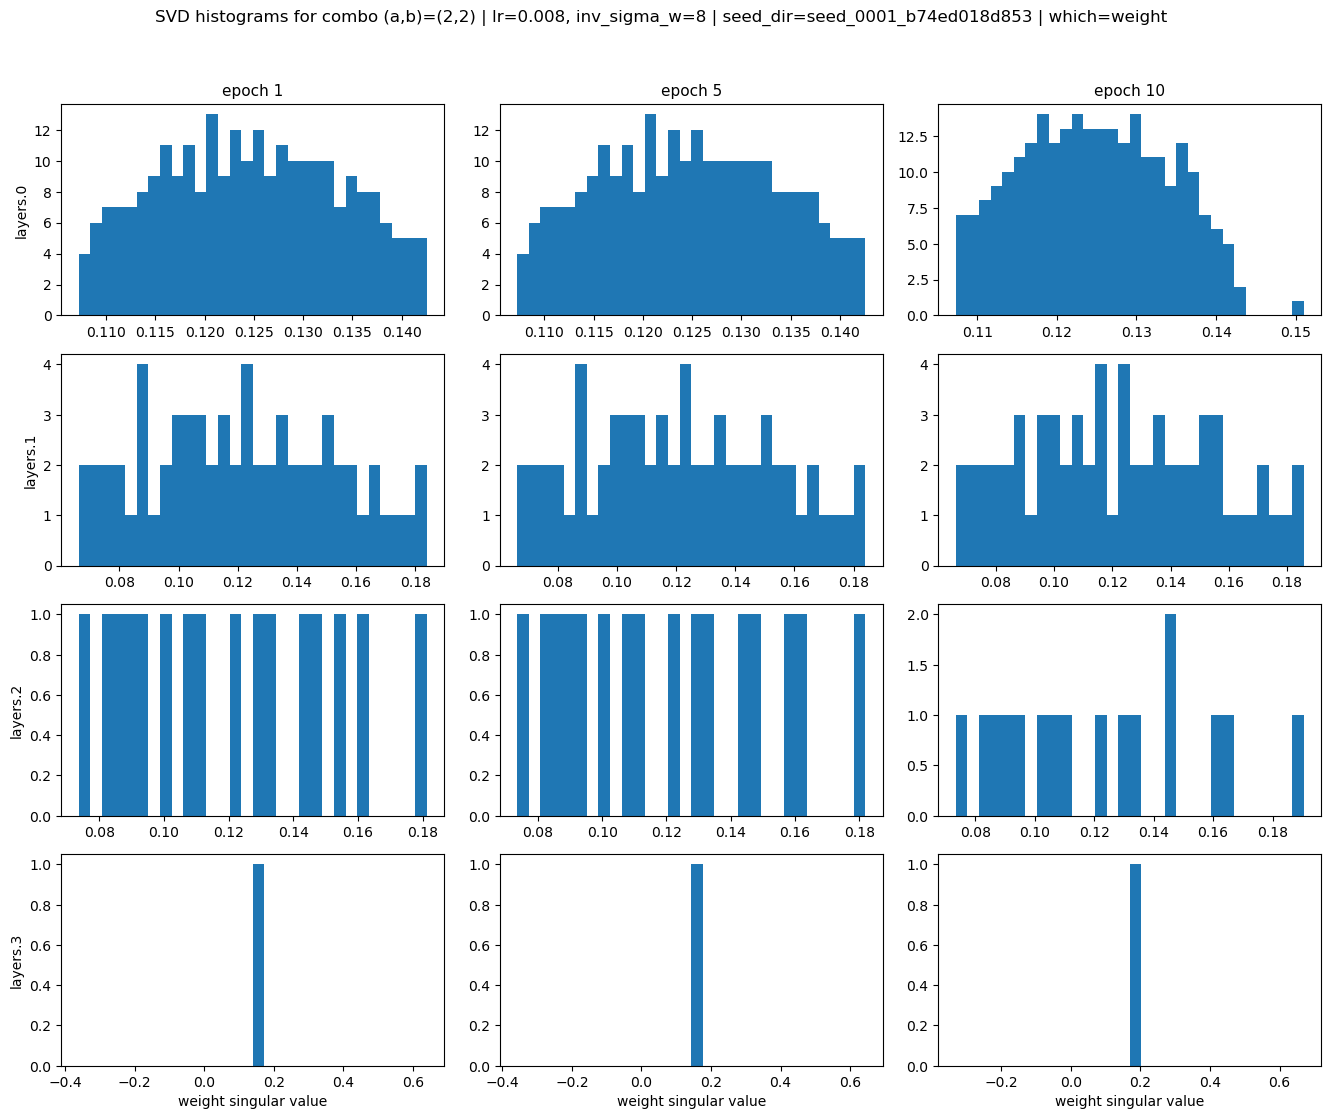

In [14]:
out = plot_svd_histograms_for_combo(
    "data/experiment_2/exp2_dnn_BIG_sgd_relu_SVD_v1",
    combo=(2, 2),
    epochs=[1, 5, 10],
    which="weight",
)
plt.show()

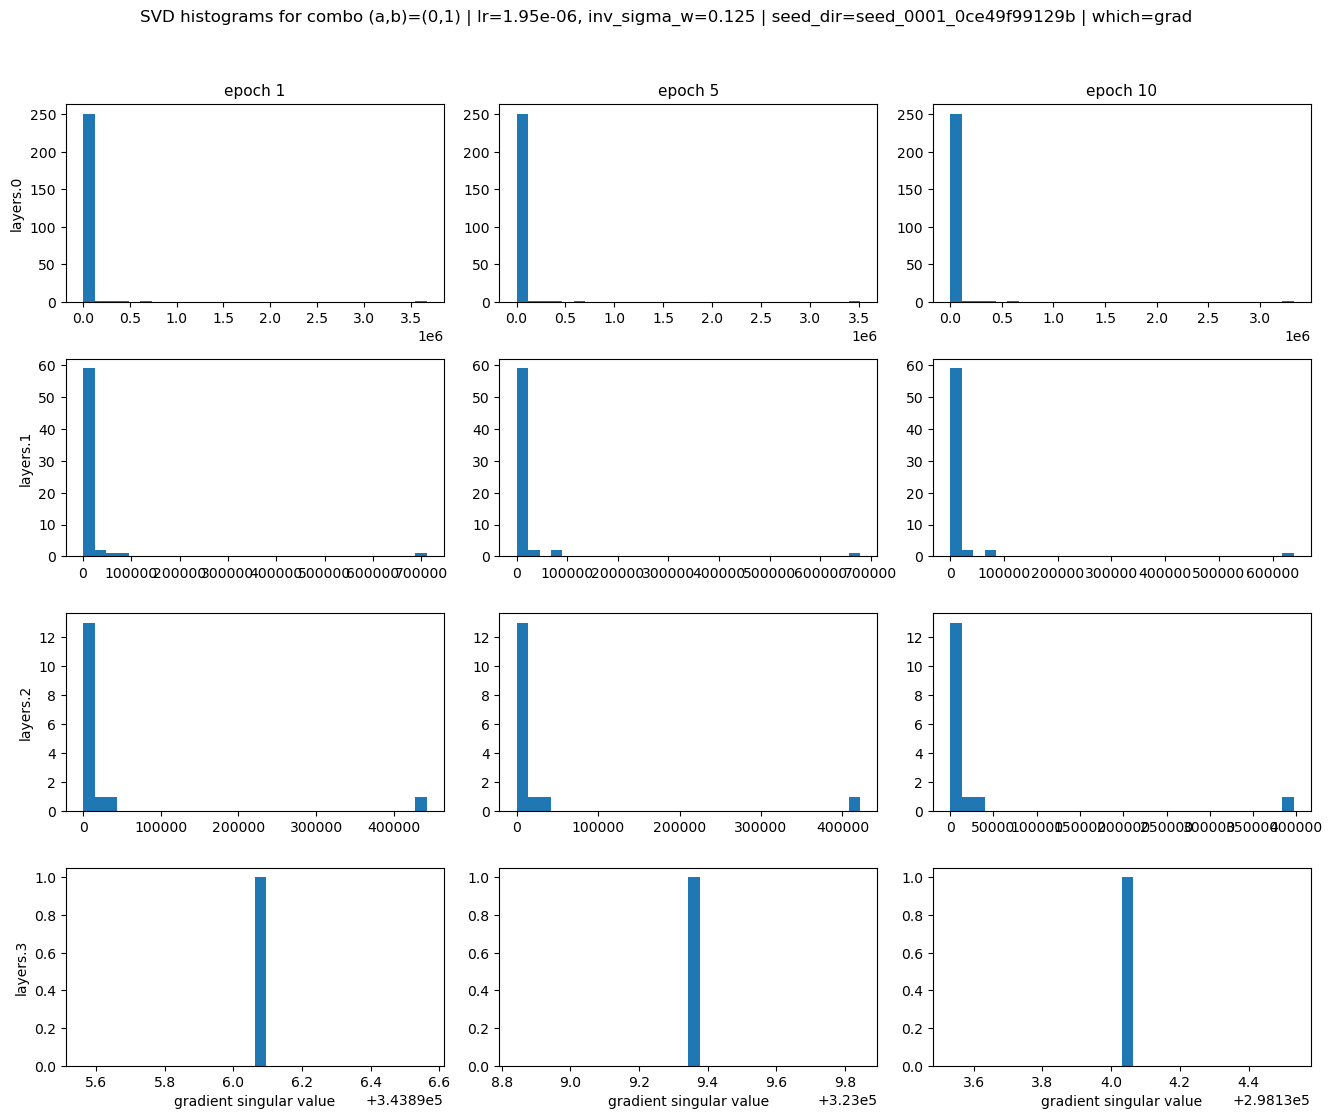

In [19]:
out = plot_svd_histograms_for_combo(
    "data/experiment_2/exp2_dnn_BIG_sgd_relu_SVD_v1",
    combo=(0,1),
    epochs=[1, 5, 10],
    which="grad",
)
plt.show()

### tanh

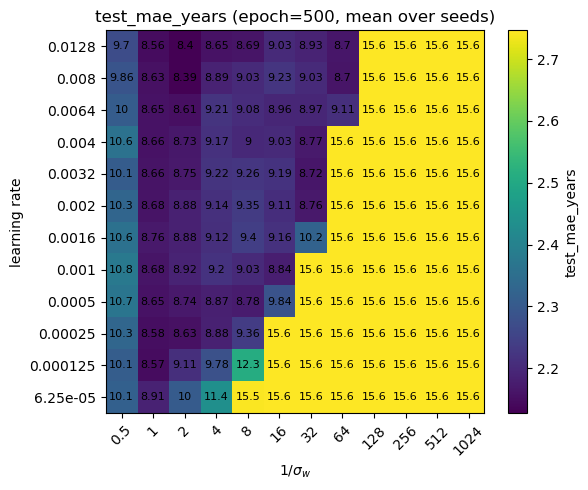

In [48]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh.npz",
    metric_key="test_mae_years",
    epoch= 500,
    annotate=True,
)
plt.show()

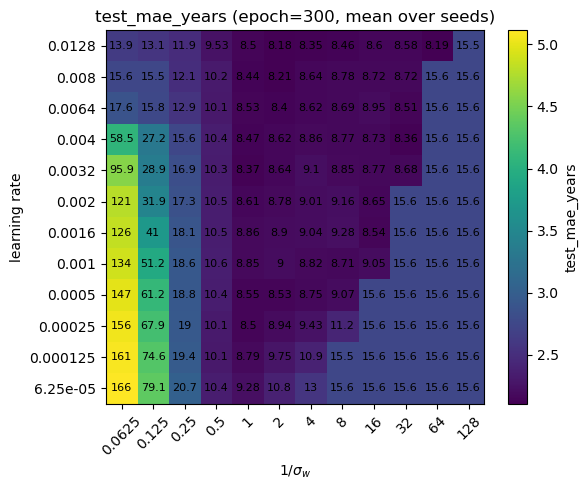

In [49]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh_v3.npz",
    metric_key="test_mae_years",
    epoch= 300,
    annotate=True,
)
plt.show()

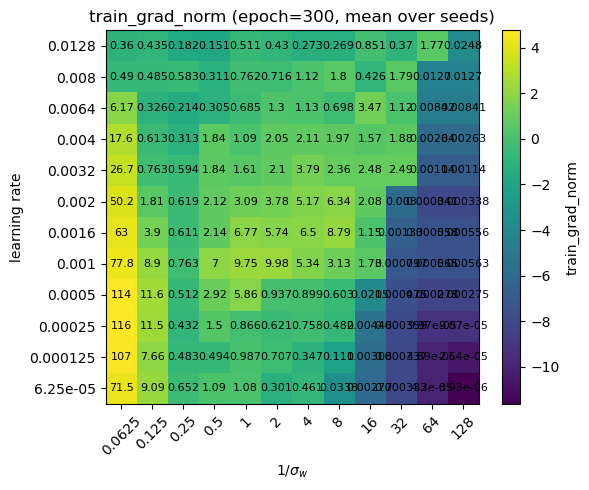

In [50]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh_v3.npz",
    metric_key="train_grad_norm",
    epoch= 300,
    annotate=True,
)
plt.show()

#### Full batch

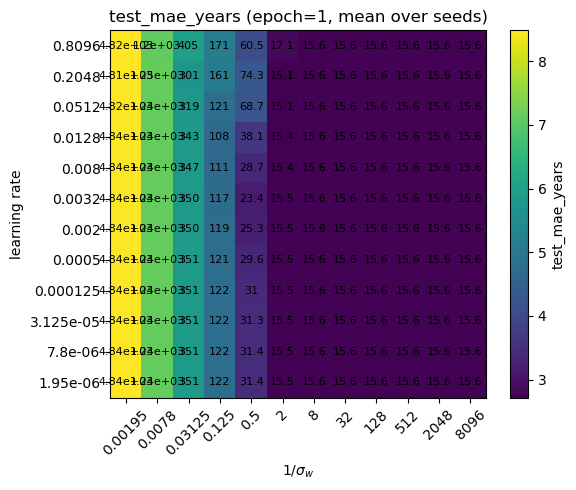

In [51]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh_full_v1.npz",
    metric_key="test_mae_years",
    epoch= 1,
    annotate=True,
)
plt.show()

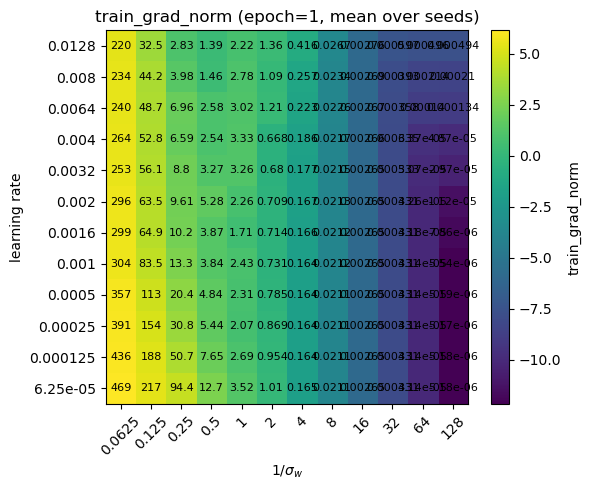

In [52]:
fig, ax, inv_vals, lr_vals, phase, counts = plot_phase_diagram_imshow(
    "collected_results/exp2_dnn_BIG_sgd_tanh_v3.npz",
    metric_key="train_grad_norm",
    epoch= 1,
    annotate=True,
)
plt.show()